# Ampliación: LSTM y Chronos-2 para PM2.5

Adaptación de los dos cuadernos opcionales de clase. Predicción a 24 horas sobre las mismas
horas medidas de 2014 que en `05_2_modelos_ml.ipynb`. No ejecuta ni modifica otros notebooks.

LSTM y Chronos-2 reciben solo PM2.5. Se comparan con naive, Gradient Boosting con las
exógenas del 05_2 y Gradient Boosting con la misma ventana de PM2.5 que la LSTM.
La comparación es exploratoria: 2014 ya se ha examinado en el proyecto.

## 1. Dependencias y configuración

Si faltan dependencias, ejecutar en una celda `%pip install "skforecast==0.25.0" "keras==3.15.1" "torch==2.14.0" "chronos-forecasting==2.3.2" ipywidgets`
y reiniciar el kernel. Keras usa PyTorch. Chronos-2 descarga sus pesos en la primera ejecución;
en CPU será más lento. Los resultados se muestran aquí, sin exportaciones.

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

from pathlib import Path
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import keras
from keras.callbacks import EarlyStopping
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skforecast.direct import ForecasterDirect
from skforecast.deep_learning import ForecasterRnn
from skforecast.deep_learning.utils import create_and_compile_model
from chronos import Chronos2Pipeline
from threadpoolctl import threadpool_limits

H = 24
UMBRAL = 150
SEMILLA = 42
VENTANA_LSTM = 72
CONTEXTO_CHRONOS = 168
MAX_EPOCHS = 20
LOTE = 256
LOTE_CHRONOS = 32
RAIZ = Path('..') if Path('../data').exists() else Path('.')
torch.set_num_threads(2)
keras.utils.set_random_seed(SEMILLA)
dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
tiempos = {}
print('Dispositivo:', dispositivo)

C:\Users\martin\Documents\Codex\2026-09-26\este-notebook-esta-en-la-mierda\work\deep_packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cpu


## 2. Datos y evaluación común

CSV principal: `data/processed/beijing_data_huecos_24h.csv`.
CSV auxiliar: `data/processed/beijing_data_preparado.csv`, para identificar imputaciones.
El historial se completa hacia delante. Los objetivos imputados nunca se evalúan.
Se predice cada hora medida del 2 de enero al 31 de diciembre de 2014 con información
disponible 24 horas antes. No se mezclan errores de los pasos 1–24.

In [2]:
df = pd.read_csv(RAIZ / 'data/processed/beijing_data_huecos_24h.csv',
                 index_col='datetime', parse_dates=True).sort_index().asfreq('h')
aux = pd.read_csv(RAIZ / 'data/processed/beijing_data_preparado.csv',
                  index_col='datetime', parse_dates=True).sort_index().asfreq('h')
marca = aux['pm2.5_imputado'].reindex(df.index)
assert marca.notna().all() and marca.isin([True, False, 0, 1]).all()
imputado = marca.astype(bool) | df['pm2.5'].isna()
y = df['pm2.5'].ffill()
exog = df.drop(columns='pm2.5')
assert y.notna().all() and exog.notna().all().all()
indice_test = y.loc['2014-01-02':'2014-12-31 23:00:00'].index
indice_test = indice_test[~imputado.loc[indice_test].to_numpy()]
predicciones = pd.DataFrame({'real': df.loc[indice_test, 'pm2.5'],
                            'naive': y.shift(H).loc[indice_test]})
print('Horas medidas:', len(indice_test), '| Horas > 150:', (predicciones['real'] > UMBRAL).sum())

Horas medidas:

 8637 | Horas > 150: 1737


## 3. Referencias de Machine Learning

Se fija la configuración ganadora de Gradient Boosting en la validación del 05_2:
7 hojas, tasa 0.05 y regularización L2 de 10. No se repite la búsqueda.
La variante sin meteorología reutiliza esa configuración, sin optimización adicional.
Los objetivos y retardos imputados reciben peso cero. El ajuste usa datos hasta 2013.

In [3]:
def referencia_ml(lags, variables):
    afectadas = imputado.copy()
    for lag in lags:
        afectadas |= imputado.shift(lag, fill_value=True)
    def pesos(index):
        return (~afectadas.loc[index]).astype(float).to_numpy()
    modelo = HistGradientBoostingRegressor(
        max_iter=200, max_leaf_nodes=7, learning_rate=0.05, l2_regularization=10,
        min_samples_leaf=30, early_stopping=False, random_state=SEMILLA)
    f = ForecasterDirect(estimator=modelo, steps=1, lags=lags, weight_func=pesos, n_jobs=1)
    with threadpool_limits(limits=2):
        f.fit(y=y.loc[:'2013'], exog=None if variables is None else variables.loc[:'2013'],
              store_in_sample_residuals=False)
        X, _ = f.create_train_X_y(y=y, exog=variables)
        return f.estimators_[1].predict(X.loc[indice_test].to_numpy()).clip(min=0)

for nombre, lags, variables in [
    ('GB 05_2', [24, 25, 26, 27, 30, 36, 48], exog),
    ('GB solo PM2.5', list(range(H, H + VENTANA_LSTM)), None),
]:
    inicio = perf_counter()
    predicciones[nombre] = referencia_ml(lags, variables)
    tiempos[nombre] = perf_counter() - inicio
    print(nombre, '| segundos:', round(tiempos[nombre], 1))

GB 05_2 | segundos: 1.4


GB solo PM2.5 | segundos: 7.9


## 4. LSTM: selección de épocas en 2013

Una LSTM de 32 unidades y una capa densa de 16 reciben 72 horas de PM2.5 y generan
los siguientes 24 pasos, como en el ejemplo de clase. Solo se evalúa el paso 24. La ventana termina en el origen.
Se usa `create_and_compile_model` y `ForecasterRnn` del ejemplo de clase para construir
la red y las secuencias. Keras ajusta las secuencias válidas en un solo lote de datos,
sin llamadas de predicción hora a hora.

Se entrena hasta 2012 y se elige el número de épocas por el MSE de las 24 salidas en 2013.
Para esta validación interna se requieren las 24 horas objetivo medidas.
El escalador solo ve el entrenamiento. Se excluyen del ajuste las ventanas o los objetivos
imputados. En validación se permite historial completado, igual que en el test.
No se buscan arquitecturas sobre 2014.

keras version: 3.15.1


Using backend: torch
torch version: 2.14.0+cpu

Epoch 1/20


C:\Users\martin\Documents\Codex\2026-09-26\este-notebook-esta-en-la-mierda\work\deep_packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)
C:\Users\martin\AppData\Local\Temp\ipykernel_21888\1169460327.py:13: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  indice = nombres['y_train'][0] + pd.Timedelta(hours=H - 1)
C:\Users\martin\AppData\Local\Temp\ipykernel_21888\1169460327.py:14: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  np.testing.assert_allclose(X[:, -1, 0], serie.loc[indice - pd.Timedel

66/66 - 6s - 87ms/step - loss: 0.0113 - val_loss: 0.0086


Epoch 2/20


...

Epoch 19/20


66/66 - 6s - 88ms/step - loss: 0.0051 - val_loss: 0.0058


Epoch 20/20


66/66 - 5s - 80ms/step - loss: 0.0051 - val_loss: 0.0058


Épocas seleccionadas: 20


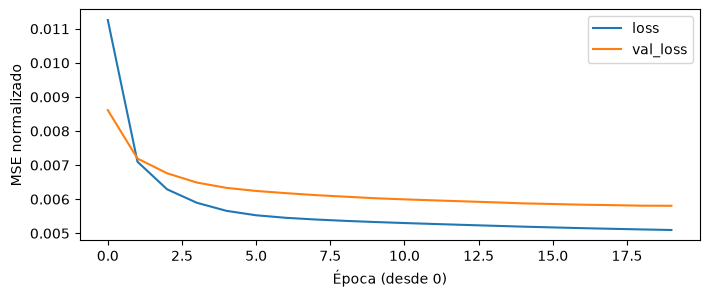

In [4]:
def entrenar_lstm(fin_train, epochs, validar=False):
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEMILLA)
    scaler = MinMaxScaler().fit(y.loc[:fin_train][~imputado.loc[:fin_train]].to_frame())
    serie = pd.DataFrame(scaler.transform(y.to_frame()), index=y.index, columns=['pm2.5'])
    lags = VENTANA_LSTM
    red = create_and_compile_model(
        series=serie.loc[:fin_train], levels=['pm2.5'], lags=lags, steps=H,
        recurrent_layer='LSTM', recurrent_units=32, dense_units=16,
        compile_kwargs={'optimizer': keras.optimizers.Adam(learning_rate=0.001), 'loss': 'mse'})
    f = ForecasterRnn(estimator=red, levels=['pm2.5'], lags=lags, transformer_series=None)
    X, _, objetivo, nombres = f.create_train_X_y(series=serie)
    indice = nombres['y_train'][0] + pd.Timedelta(hours=H - 1)
    np.testing.assert_allclose(X[:, -1, 0], serie.loc[indice - pd.Timedelta(hours=H), 'pm2.5'], rtol=1e-5, atol=1e-6)
    np.testing.assert_allclose(objetivo[:, -1, 0], serie.loc[indice, 'pm2.5'], rtol=1e-5, atol=1e-6)
    historial_imputado = imputado.rolling(VENTANA_LSTM, min_periods=VENTANA_LSTM).max().shift(H)
    objetivos_imputados = imputado.rolling(H, min_periods=H).max().loc[indice].fillna(1).astype(bool)
    aptas = ~objetivos_imputados & ~historial_imputado.loc[indice].fillna(1).astype(bool)
    train = (indice <= pd.Timestamp(fin_train)) & aptas.to_numpy()
    opciones = {}
    if validar:
        valid = ((indice >= pd.Timestamp('2013-01-02')) & (indice <= pd.Timestamp('2013-12-31 23:00:00'))
                 & ~objetivos_imputados.to_numpy())
        opciones = {'validation_data': (X[valid], objetivo[valid]),
                    'callbacks': [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]}
    historia = red.fit(X[train], objetivo[train], epochs=epochs, batch_size=LOTE,
                       shuffle=False, verbose=2, **opciones)
    return red, scaler, X, indice, historia.history

inicio = perf_counter()
_, _, _, _, historia = entrenar_lstm('2012-12-31 23:00:00', MAX_EPOCHS, validar=True)
epocas = int(np.argmin(historia['val_loss']) + 1)
tiempos['Selección LSTM'] = perf_counter() - inicio
print('Épocas seleccionadas:', epocas)
pd.DataFrame(historia).plot(xlabel='Época (desde 0)', ylabel='MSE normalizado', figsize=(8, 3))
plt.show()

## 5. LSTM: reajuste y test

Se reinicia la red y se reajusta con los datos hasta diciembre de 2013 durante el número
de épocas elegido. El modelo queda fijo durante 2014; el historial se actualiza por origen.

In [5]:
inicio = perf_counter()
red, scaler, X, indice, _ = entrenar_lstm('2013-12-31 23:00:00', epocas)
posiciones = indice.get_indexer(indice_test)
assert (posiciones >= 0).all()
pred = red.predict(X[posiciones], batch_size=LOTE, verbose=0)[:, -1, :]
predicciones['LSTM'] = scaler.inverse_transform(pred).ravel().clip(min=0)
tiempos['LSTM ajuste y test'] = perf_counter() - inicio

keras version: 3.15.1
Using backend: torch
torch version: 2.14.0+cpu

Epoch 1/20


C:\Users\martin\Documents\Codex\2026-09-26\este-notebook-esta-en-la-mierda\work\deep_packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)
C:\Users\martin\AppData\Local\Temp\ipykernel_21888\1169460327.py:13: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  indice = nombres['y_train'][0] + pd.Timedelta(hours=H - 1)
C:\Users\martin\AppData\Local\Temp\ipykernel_21888\1169460327.py:14: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  np.testing.assert_allclose(X[:, -1, 0], serie.loc[indice - pd.Timedel

90/90 - 7s - 81ms/step - loss: 0.0103


Epoch 2/20


90/90 - 7s - 81ms/step - loss: 0.0067


...

90/90 - 7s - 77ms/step - loss: 0.0052


Epoch 19/20


90/90 - 7s - 77ms/step - loss: 0.0052


Epoch 20/20


90/90 - 7s - 77ms/step - loss: 0.0052


## 6. Chronos-2: predicción zero-shot

Se carga `amazon/chronos-2`, como en el cuaderno de clase. No se reajustan sus pesos.
Cada origen recibe sus últimas 168 horas de PM2.5, sin meteorología futura ni objetivos.
Se calcula la mediana del paso 24. Los orígenes se procesan en lotes independientes
(`cross_learning=False`) para impedir que un origen comparta información con otro posterior.

Chronos-2 usa más historial que la LSTM; se comparan estas configuraciones, no arquitecturas
con entradas idénticas. No se ha verificado si Beijing forma parte de su preentrenamiento,
por lo que el resultado zero-shot no demuestra una evaluación libre de solapamiento.

In [6]:
inicio = perf_counter()
pipeline = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map=dispositivo,
                                             revision='29ec3766d36d6f73f0696f85560a422f50e8498c')
tiempos['Carga Chronos-2'] = perf_counter() - inicio
origenes = indice_test - pd.Timedelta(hours=H)
pos_origen = y.index.get_indexer(origenes)
assert (pos_origen >= CONTEXTO_CHRONOS - 1).all()
ventanas = np.lib.stride_tricks.sliding_window_view(y.to_numpy(dtype='float32'), CONTEXTO_CHRONOS)
contextos = ventanas[pos_origen - CONTEXTO_CHRONOS + 1].copy()
np.testing.assert_allclose(contextos[:, -1], y.loc[origenes].to_numpy(), rtol=1e-6)

inicio = perf_counter()
pronosticos = []
for inicio_lote in range(0, len(contextos), LOTE_CHRONOS):
    lote = torch.from_numpy(contextos[inicio_lote:inicio_lote + LOTE_CHRONOS, None, :])
    _, medianas = pipeline.predict_quantiles(
        lote, prediction_length=H, quantile_levels=[0.5],
        batch_size=LOTE_CHRONOS, cross_learning=False)
    pronosticos.extend(float(mediana.reshape(-1)[H - 1]) for mediana in medianas)
    if inicio_lote % (LOTE_CHRONOS * 16) == 0:
        print(f'Chronos-2: {min(inicio_lote + LOTE_CHRONOS, len(contextos))}/{len(contextos)}', flush=True)
predicciones['Chronos-2'] = np.maximum(pronosticos, 0)
tiempos['Chronos-2 inferencia'] = perf_counter() - inicio

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   8%|▊         | 13/170 [00:00<00:01, 129.56it/s]

Loading weights:  15%|█▌        | 26/170 [00:00<00:01, 87.38it/s] 

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 590.24it/s]


C:\Users\martin\AppData\Local\Temp\ipykernel_21888\2674527463.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  origenes = indice_test - pd.Timedelta(hours=H)


...

Chronos-2: 6176/8637


Chronos-2: 6688/8637


Chronos-2: 7200/8637


Chronos-2: 7712/8637


Chronos-2: 8224/8637


## 7. ¿Mejoran la predicción?

RMSE, MAE y skill respecto a naive sobre horas idénticas. Un skill positivo indica mejora.
La reducción frente a GB 05_2 compara con la referencia principal; puede ser negativa.
Las horas altas son aquellas cuya concentración real supera 150 µg/m³. No se evalúan alertas.

In [7]:
assert predicciones.notna().all().all() and np.isfinite(predicciones.to_numpy()).all()
filas = []
for grupo, mascara in {'global': predicciones['real'].notna(), '> 150': predicciones['real'] > UMBRAL}.items():
    datos = predicciones.loc[mascara]
    base = np.sqrt(mean_squared_error(datos['real'], datos['naive']))
    referencia = np.sqrt(mean_squared_error(datos['real'], datos['GB 05_2']))
    for nombre in datos.columns.drop('real'):
        error = np.sqrt(mean_squared_error(datos['real'], datos[nombre]))
        filas.append({'subconjunto': grupo, 'modelo': nombre, 'n': len(datos), 'RMSE': error,
                      'MAE': mean_absolute_error(datos['real'], datos[nombre]),
                      'skill_RMSE': 1 - error / base, 'mejora_vs_GB_%': 100 * (1 - error / referencia)})
resultados = pd.DataFrame(filas).set_index(['subconjunto', 'modelo'])
display(resultados.round(3))
display(pd.Series(tiempos, name='segundos').round(1).to_frame())
for nombre in ['LSTM', 'Chronos-2']:
    mejora = resultados.loc[('global', nombre), 'mejora_vs_GB_%']
    alta = resultados.loc[('> 150', nombre), 'mejora_vs_GB_%']
    print(f'{nombre}: reducción de RMSE frente a GB 05_2: {mejora:.1f}% global; {alta:.1f}% en horas altas.')

n     RMSE      MAE  skill_RMSE  mejora_vs_GB_%
subconjunto modelo                                                           
global      naive          8637   99.624   67.789       0.000         -22.220
            GB 05_2        8637   81.512   59.866       0.182           0.000
            GB solo PM2.5  8637   87.395   62.257       0.123          -7.217
            LSTM           8637   84.753   61.361       0.149          -3.976
            Chronos-2      8637   96.096   66.067       0.035         -17.892
> 150       naive          1737  131.965  107.978       0.000           1.629
            GB 05_2        1737  134.150  111.888      -0.017           0.000
            GB solo PM2.5  1737  151.609  125.516      -0.149         -13.015
            LSTM           1737  153.825  132.559      -0.166         -14.667
            Chronos-2      1737  164.287  138.749      -0.245         -22.466

,segundos
GB 05_2,1.4
GB solo PM2.5,7.9
Selección LSTM,116.2
LSTM ajuste y test,141.5
Carga Chronos-2,1.4
Chronos-2 inferencia,239.9


LSTM: reducción de RMSE frente a GB 05_2: -4.0% global; -14.7% en horas altas.
Chronos-2: reducción de RMSE frente a GB 05_2: -17.9% global; -22.5% en horas altas.


## 8. Comparación visual

Se conservan las ventanas de enero y julio del 05_2. Los huecos no se conectan en el gráfico.
Se valoran conjuntamente el error global, el error durante concentraciones altas y el tiempo.
Una sola ejecución de LSTM no caracteriza su variabilidad entre semillas.

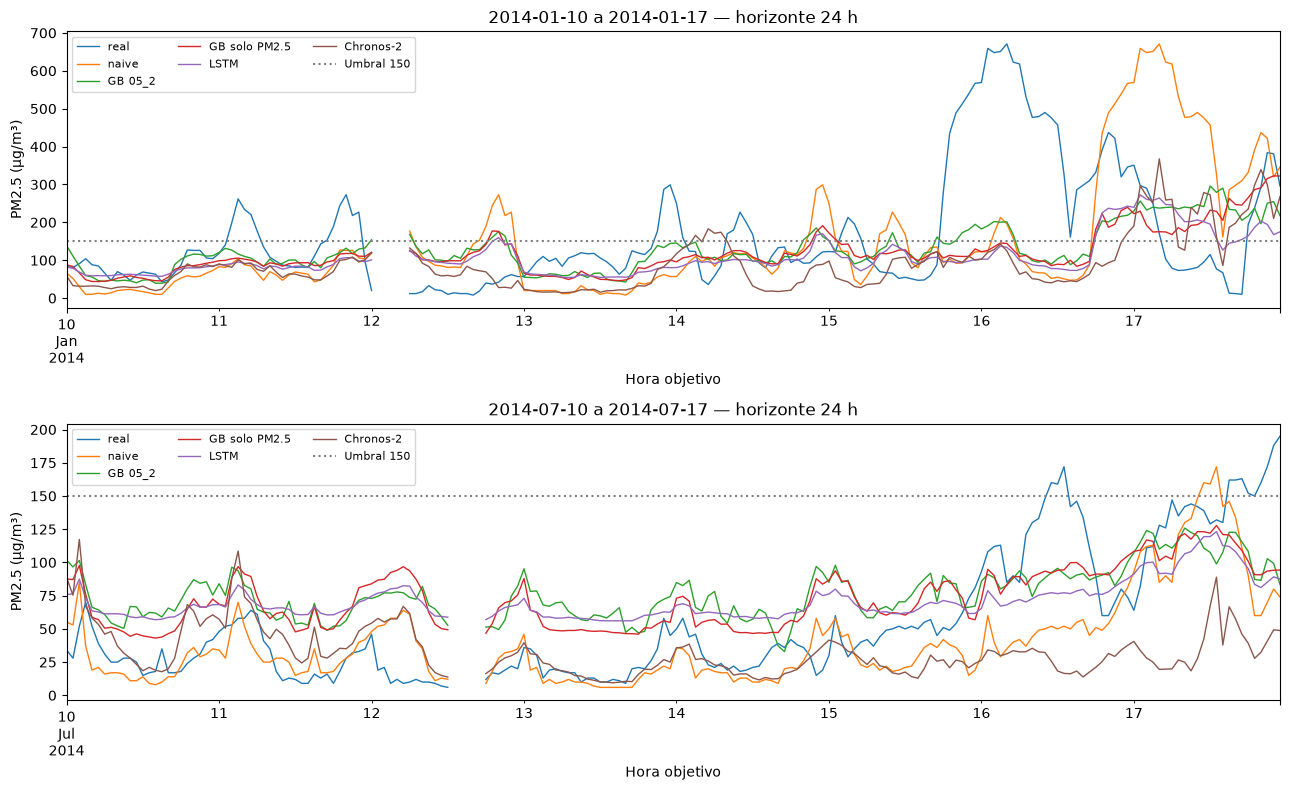

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
for ax, (inicio, fin) in zip(axes, [('2014-01-10', '2014-01-17'), ('2014-07-10', '2014-07-17')]):
    predicciones.loc[inicio:fin].asfreq('h').plot(ax=ax, linewidth=1)
    ax.axhline(UMBRAL, color='grey', linestyle=':', label='Umbral 150')
    ax.set(title=f'{inicio} a {fin} — horizonte 24 h', ylabel='PM2.5 (µg/m³)', xlabel='Hora objetivo')
    ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

Referencias: cuadernos `AA_ST_DeepLearning_Opcional_26_27.ipynb` y
`AA_ST_FoundationModel_Chronos2_Opcional_26_27_v2.ipynb`.
[Skforecast RNN](https://skforecast.org/0.25.0/api/forecasterrnn) ·
[Chronos-2](https://github.com/amazon-science/chronos-forecasting).